In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [3]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})
X = df['review']
y = df['sentiment']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [7]:
model = Sequential()
model.add(Embedding(max_words, 128, input_length=max_len))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
model.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 150s 300ms/step - accuracy: 0.9045 - loss: 0.2475 - val_accuracy: 0.8825 - val_loss: 0.3001
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 145s 291ms/step - accuracy: 0.9362 - loss: 0.1739 - val_accuracy: 0.8824 - val_loss: 0.3131
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 287ms/step - accuracy: 0.9547 - loss: 0.1316 - val_accuracy: 0.8752 - val_loss: 0.3396
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 285ms/step - accuracy: 0.9638 - loss: 0.1028 - val_accuracy: 0.8674 - val_loss: 0.4087
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 284ms/step - accuracy: 0.9748 - loss: 0.0775 - val_accuracy: 0.8611 - val_loss: 0.4236


In [10]:
loss, acc = model.evaluate(X_test_pad, y_test)
print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.8568 - loss: 0.4078
0.864799976348877


313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step


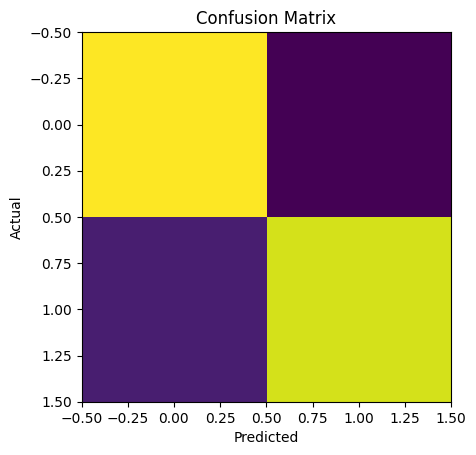

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
def predict_review(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(pad)[0][0]
    if pred > 0.5:
        return "Positive", float(pred)
    else:
        return "Negative", float(pred)

In [17]:
print(predict_review("Worst movie I have ever seen"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
('Negative', 0.014551891945302486)


In [18]:
review = "This movie was amazing with great acting"
print(predict_review(review))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
('Positive', 0.9781259298324585)
